Лабораторна робота №7

Виконав: Верещака Олександр ПР-2-2
Варіант №1

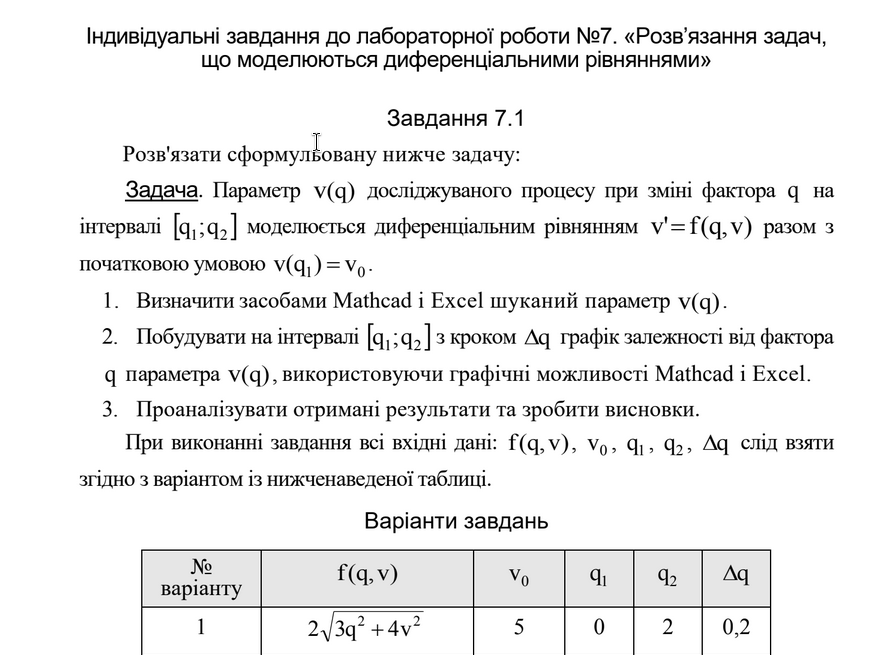

Розв'язок диференціального рівняння (таблиця значень):
---------------------------------------------
 Фактор (q)  Параметр v(q)
        0.0       5.000000
        0.2      11.127479
        0.4      24.770956
        0.6      55.125082
        0.8     122.633651
        1.0     273.078958
        1.2     607.284630
        1.4    1352.382230
        1.6    3008.391379
        1.8    6695.051706
        2.0   14902.948357
---------------------------------------------


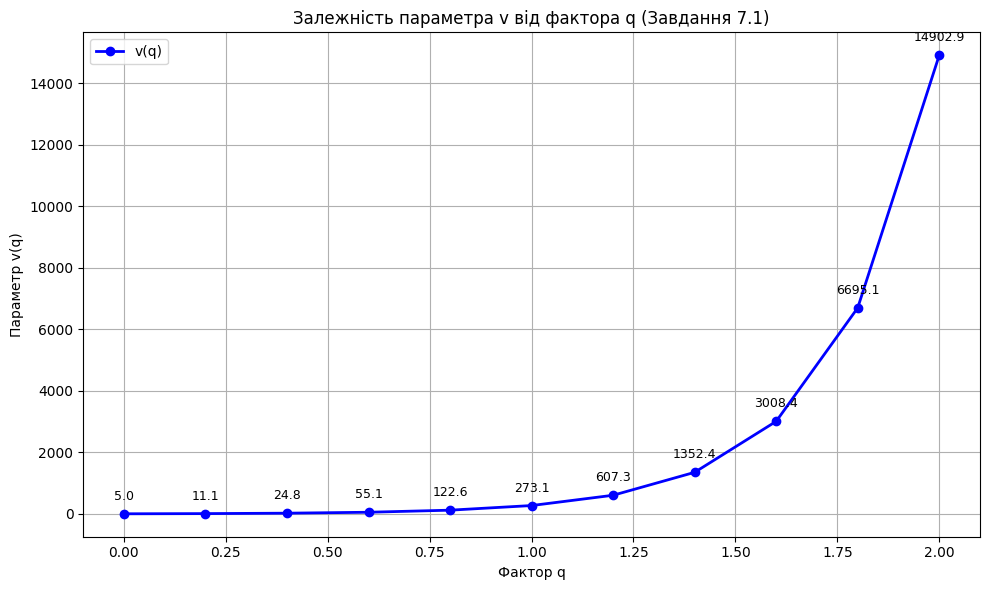

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import pandas as pd

# ==========================================
# Вхідні дані (Завдання 7.1, Варіант 1)
# ==========================================
q1 = 0.0
q2 = 2.0
dq = 0.2
v0 = 5.0

# Функція, що описує диференціальне рівняння: v' = f(q, v)
# solve_ivp вимагає, щоб функція приймала аргументи у порядку (t, y) -> у нас це (q, v)
def f(q, v):
    # v передається як масив, тому беремо нульовий елемент v[0]
    return 2 * np.sqrt(3 * q**2 + 4 * v[0]**2)

# ==========================================
# 1. Розв'язання диференціального рівняння (Аналог Mathcad)
# ==========================================
# Створюємо масив точок q з кроком dq (від 0 до 2 з кроком 0.2)
q_eval = np.arange(q1, q2 + dq/2, dq)

# Розв'язуємо задачу Коші чисельним методом (Рунге-Кутти 4(5) порядку)
sol = solve_ivp(f, [q1, q2], [v0], t_eval=q_eval)

q_vals = sol.t
v_vals = sol.y[0]

# ==========================================
# 2. Створення таблиці (Аналог Excel)
# ==========================================
results = {
    "Фактор (q)": q_vals,
    "Параметр v(q)": v_vals
}
df = pd.DataFrame(results)

print("Розв'язок диференціального рівняння (таблиця значень):")
print("-" * 45)
print(df.to_string(index=False))
print("-" * 45)

# ==========================================
# 3. Побудова графіка
# ==========================================
plt.figure(figsize=(10, 6))

# Будуємо лінію з маркерами точок
plt.plot(q_vals, v_vals, 'b-o', linewidth=2, markersize=6, label="v(q)")

# Додаємо підписи значень біля кожної точки (як це часто роблять в Excel)
for i in range(len(q_vals)):
    plt.annotate(f"{v_vals[i]:.1f}", (q_vals[i], v_vals[i]), 
                 textcoords="offset points", xytext=(0,10), ha='center', fontsize=9)

plt.title("Залежність параметра v від фактора q (Завдання 7.1)")
plt.xlabel("Фактор q")
plt.ylabel("Параметр v(q)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

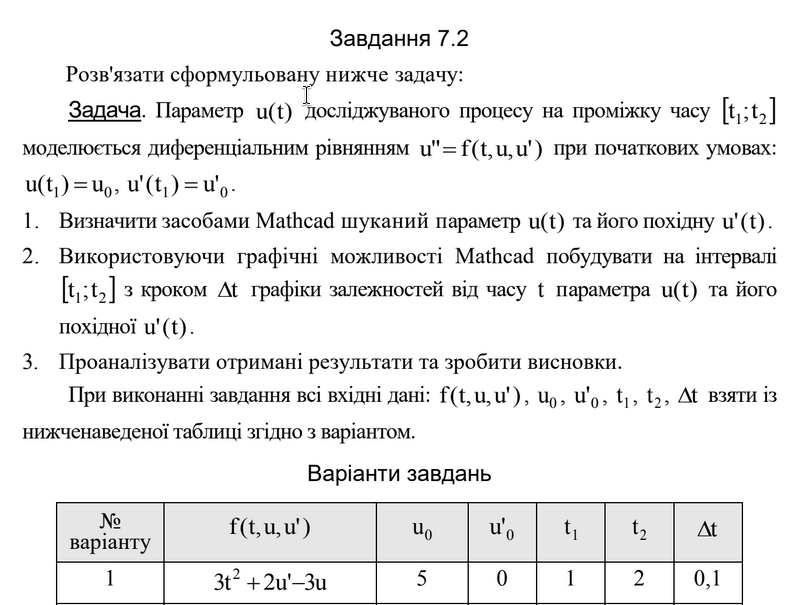

Завдання 7.2 (Варіант 1) - Розв'язок ДР 2-го порядку
------------------------------------------------------------
 Час (t)  Параметр u(t)  Похідна u'(t)
     1.0       5.000000       0.000000
     1.1       4.937032      -1.288713
     1.2       4.736655      -2.747048
     1.3       4.382479      -4.358109
     1.4       3.860679      -6.095637
     1.5       3.160442      -7.923134
     1.6       2.275106      -9.792864
     1.7       1.202791     -11.646203
     1.8      -0.051547     -13.412380
     1.9      -1.474411     -15.006832
     2.0      -3.043766     -16.331211
------------------------------------------------------------


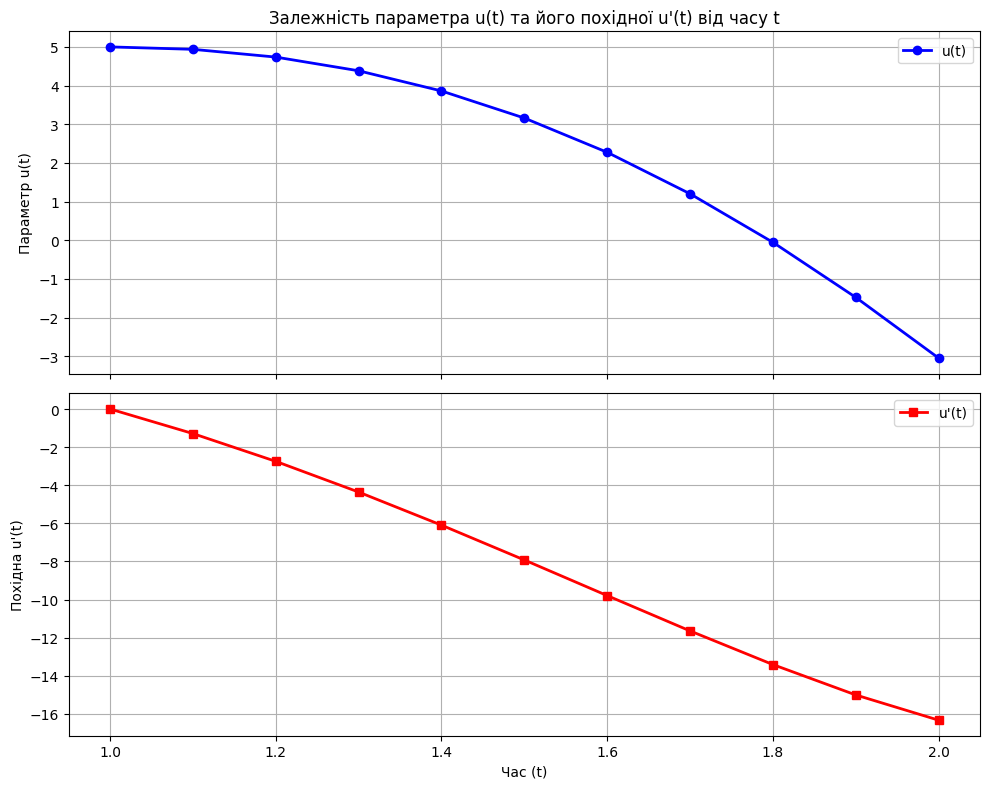

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import pandas as pd

# ==========================================
# Вхідні дані (Завдання 7.2, Варіант 1)
# ==========================================
t1 = 1.0
t2 = 2.0
dt = 0.1
u0 = 5.0        # Початкове значення u(t)
u_prime0 = 0.0  # Початкове значення u'(t)

# ==========================================
# 1. Формування системи диференціальних рівнянь
# ==========================================
# Функція приймає час t та масив y, де y[0] - це u, а y[1] - це u'
def system(t, y):
    u = y[0]
    u_prime = y[1]
    
    # Перше рівняння: похідна від u дорівнює u'
    dy1 = u_prime
    # Друге рівняння: u'' = f(t, u, u')
    dy2 = 3 * t**2 + 2 * u_prime - 3 * u
    
    return [dy1, dy2]

# Сітка часу з заданим кроком
t_eval = np.arange(t1, t2 + dt/2, dt)

# Рахуємо точну кількість точок: (2.0 - 1.0) / 0.1 = 10 кроків, тобто 11 точок
n_steps = int(round((t2 - t1) / dt)) + 1

# Сітка часу, яка гарантовано починається рівно в t1 і закінчується рівно в t2
t_eval = np.linspace(t1, t2, n_steps)

# Розв'язання системи
sol = solve_ivp(system, [t1, t2], [u0, u_prime0], t_eval=t_eval)

# Витягуємо результати
t_vals = sol.t
u_vals = sol.y[0]       # Значення самої функції u(t)
u_prime_vals = sol.y[1] # Значення похідної u'(t)

# ==========================================
# 2. Створення таблиці результатів
# ==========================================
results = {
    "Час (t)": t_vals,
    "Параметр u(t)": u_vals,
    "Похідна u'(t)": u_prime_vals
}
df = pd.DataFrame(results)

print("Завдання 7.2 (Варіант 1) - Розв'язок ДР 2-го порядку")
print("-" * 60)
print(df.to_string(index=False))
print("-" * 60)

# ==========================================
# 3. Побудова графіків
# ==========================================
# Створюємо два графіки один під одним (subplots) для кращої наочності
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Графік самої функції u(t)
ax1.plot(t_vals, u_vals, 'b-o', linewidth=2, label="u(t)")
ax1.set_title("Залежність параметра u(t) та його похідної u'(t) від часу t")
ax1.set_ylabel("Параметр u(t)")
ax1.grid(True)
ax1.legend()

# Графік похідної u'(t)
ax2.plot(t_vals, u_prime_vals, 'r-s', linewidth=2, label="u'(t)")
ax2.set_xlabel("Час (t)")
ax2.set_ylabel("Похідна u'(t)")
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()

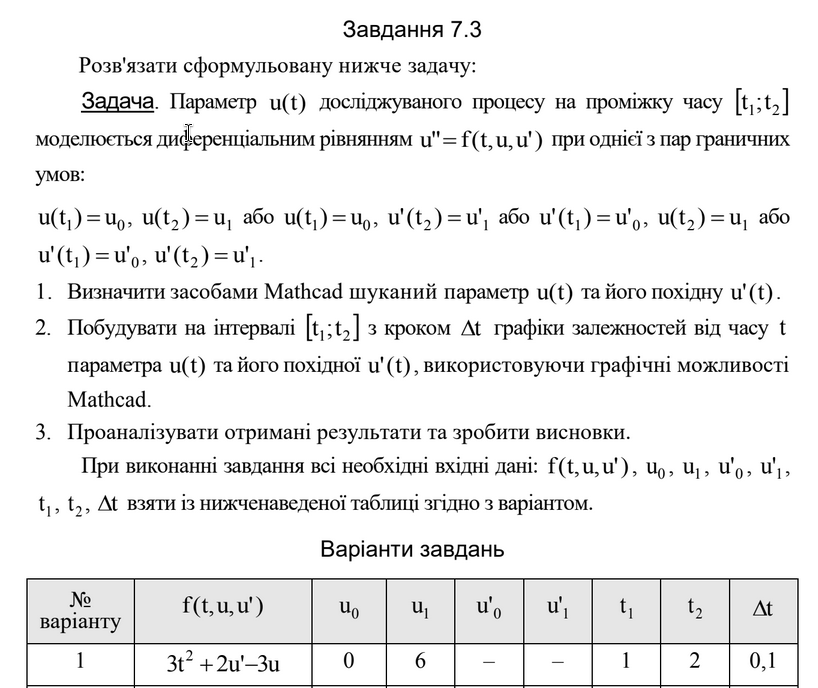

Завдання 7.3 (Варіант 1) - Розв'язок крайової задачі
-----------------------------------------------------------------
 Час (t)  Параметр u(t)  Похідна u'(t)
     1.0       0.000000       0.880165
     1.1       0.114037       1.423493
     1.2       0.289564       2.112728
     1.3       0.541986       2.963968
     1.4       0.888238       3.991507
     1.5       1.346556       5.206964
     1.6       1.936167       6.618305
     1.7       2.676863       8.228769
     1.8       3.588480      10.035719
     1.9       4.690243      12.029422
     2.0       6.000000      14.191805
-----------------------------------------------------------------


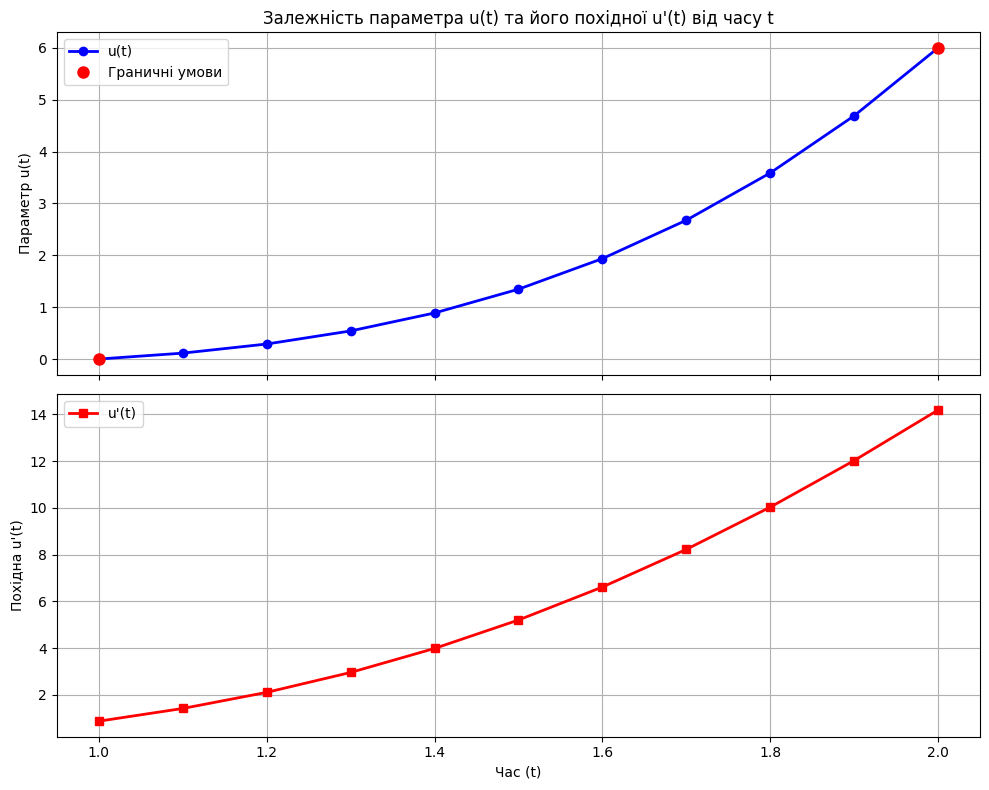

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_bvp
import pandas as pd

# ==========================================
# Вхідні дані (Завдання 7.3, Варіант 1)
# ==========================================
t1 = 1.0
t2 = 2.0
dt = 0.1
u0 = 0.0  # Гранична умова зліва: u(t1) = 0
u1 = 6.0  # Гранична умова справа: u(t2) = 6

# ==========================================
# 1. Формування системи ДР та граничних умов
# ==========================================
# Функція, що описує систему. Для solve_bvp вона має повертати масив 2D
def system(t, y):
    u = y[0]
    u_prime = y[1]
    
    dy1 = u_prime
    dy2 = 3 * t**2 + 2 * u_prime - 3 * u
    
    # Використовуємо vstack для правильного формату (SciPy вимагає 2D масив)
    return np.vstack((dy1, dy2))

# Функція граничних умов
# ya - значення функції та похідної на лівому кінці (t1)
# yb - значення функції та похідної на правому кінці (t2)
def bc(ya, yb):
    # Нам потрібно, щоб ya[0] (тобто u(t1)) дорівнювало u0
    # і yb[0] (тобто u(t2)) дорівнювало u1.
    # Функція має повертати нулі, коли умови виконані.
    return np.array([ya[0] - u0, yb[0] - u1])

# ==========================================
# 2. Розв'язання крайової задачі
# ==========================================
# Створюємо сітку точок
n_steps = int(round((t2 - t1) / dt)) + 1
t_eval = np.linspace(t1, t2, n_steps)

# solve_bvp вимагає початкового наближення.
# Зробимо лінійне наближення від u0 до u1 для самої функції
y_guess = np.zeros((2, t_eval.size))
y_guess[0] = np.linspace(u0, u1, t_eval.size)
y_guess[1] = (u1 - u0) / (t2 - t1) # Похідна від прямої лінії

# Вирішуємо задачу
sol = solve_bvp(system, bc, t_eval, y_guess)

# Витягуємо точні результати на нашій сітці
y_eval = sol.sol(t_eval)
u_vals = y_eval[0]
u_prime_vals = y_eval[1]

# ==========================================
# 3. Створення таблиці
# ==========================================
results = {
    "Час (t)": t_eval,
    "Параметр u(t)": u_vals,
    "Похідна u'(t)": u_prime_vals
}
df = pd.DataFrame(results)

print("Завдання 7.3 (Варіант 1) - Розв'язок крайової задачі")
print("-" * 65)
print(df.to_string(index=False))
print("-" * 65)

# ==========================================
# 4. Побудова графіків
# ==========================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Графік u(t)
ax1.plot(t_eval, u_vals, 'b-o', linewidth=2, label="u(t)")
# Виділяємо наші граничні (крайові) умови червоними точками
ax1.plot([t1, t2], [u0, u1], 'ro', markersize=8, label="Граничні умови")
ax1.set_title("Залежність параметра u(t) та його похідної u'(t) від часу t")
ax1.set_ylabel("Параметр u(t)")
ax1.grid(True)
ax1.legend()

# Графік u'(t)
ax2.plot(t_eval, u_prime_vals, 'r-s', linewidth=2, label="u'(t)")
ax2.set_xlabel("Час (t)")
ax2.set_ylabel("Похідна u'(t)")
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()